# Treinamento e Avaliação de Modelo LSTM
Este notebook cria um fluxo completo para treinar e avaliar um modelo LSTM em séries temporais de produção/exportação de carnes brasileiras.
Usaremos as métricas: MSE, RMSE e R².

In [1]:
# Instale as dependências necessárias caso ainda não estejam disponíveis.
# Execute esta célula apenas uma vez no ambiente Jupyter.

# !pip install pandas numpy scikit-learn matplotlib tensorflow


In [2]:
# Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Carregar dados
PATH = "/content/carne-brasileira-exportada.csv"
df = pd.read_csv(PATH)
df.head()

,ano,trimestre,tipo_carne,producao_cabecas_anual_mi,abate_cabecas,peso_carcaca_ton,exportacao_usd,media_cambio_usdbrl,custo_milho_rs,custo_soja_rs,preco_medio_ton_usd
0,2014,1,bovino,212.34,8.366,1.951,1.345,2.34,22.57,62.01,4.403
1,2014,2,bovino,212.34,8.516,2.006,1.384,2.22,23.59,61.42,4.729
2,2014,3,bovino,212.34,8.456,2.036,1.547,2.28,19.97,56.50,4.874
3,2014,4,bovino,212.34,8.525,2.058,1.519,2.59,21.46,56.73,4.858
4,2014,1,suino,37.93,8.686,0.747,0.260,2.34,22.57,62.01,2.811


In [3]:
# Pré-processamento básico
# Usamos dados ordenados por data, filtrando um tipo de carne para uma série temporal consistente.
meat_type = "bovino"  # altere para 'suino' ou 'frango' conforme desejado
feature_column = "preco_medio_ton_usd"  # alvo da previsão

filtered = df[df["tipo_carne"] == meat_type].copy()
filtered["date"] = pd.to_datetime(filtered["ano"].astype(str) + "Q" + filtered["trimestre"].astype(str))
filtered = filtered.sort_values("date").reset_index(drop=True)

print(f"Tipo de carne: {meat_type}")
print(filtered[["date", feature_column]].head())

series = filtered[[feature_column]].astype(float)
scaler = MinMaxScaler(feature_range=(0, 1))
series_scaled = scaler.fit_transform(series)

train_size = int(len(series_scaled) * 0.8)
train_data = series_scaled[:train_size]
test_data = series_scaled[train_size:]

print(f"Tamanho de treino: {len(train_data)}")
print(f"Tamanho de teste: {len(test_data)}")

Tipo de carne: bovino
        date  preco_medio_ton_usd
0 2014-01-01                4.403
1 2014-04-01                4.729
2 2014-07-01                4.874
3 2014-10-01                4.858
4 2015-01-01                4.279
Tamanho de treino: 35
Tamanho de teste: 9


/tmp/ipykernel_24607/208841149.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  filtered["date"] = pd.to_datetime(filtered["ano"].astype(str) + "Q" + filtered["trimestre"].astype(str))


In [4]:
# Função utilitária para criar sequências de time series

def create_sequences(data, seq_len):
    x, y = [], []
    for i in range(len(data) - seq_len):
        x.append(data[i:i + seq_len])
        y.append(data[i + seq_len])
    return np.array(x), np.array(y)

sequence_length = 4  # usando 4 trimestres para prever o próximo trimestre
x_train, y_train = create_sequences(train_data, sequence_length)
x_test, y_test = create_sequences(test_data, sequence_length)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

x_train shape: (31, 4, 1)
y_train shape: (31, 1)
x_test shape: (5, 4, 1)
y_test shape: (5, 1)


In [5]:
# Construir o modelo LSTM
model = Sequential([
    LSTM(64, activation="tanh", input_shape=(sequence_length, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation="tanh"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 4, 64)          │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Treinar o modelo com early stopping
early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = model.fit(
    x_train,
    y_train,
    epochs=150,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 244ms/step - loss: 0.0313 - val_loss: 0.4157
Epoch 2/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0241 - val_loss: 0.3698
Epoch 3/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0171 - val_loss: 0.3241
Epoch 4/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0121 - val_loss: 0.2783
Epoch 5/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0094 - val_loss: 0.2347
Epoch 6/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0090 - val_loss: 0.2034
Epoch 7/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0080 - val_loss: 0.1932
Epoch 8/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0092 - val_loss: 0.1976
Epoch 9/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0079 - val_loss: 0.2067
Epoch 10/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0074 - val_loss: 0.2192
Epoch 11/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0075 - val_loss: 0.2304
Epoch 12/150
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0080 - val_l

In [7]:
# Previsões e avaliação
predictions_scaled = model.predict(x_test)

# Inverter a escala para métricas reais
predictions = scaler.inverse_transform(predictions_scaled)
actuals = scaler.inverse_transform(y_test)

mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(actuals, predictions)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
MSE: 0.0508
RMSE: 0.2254
R²: -2.2100


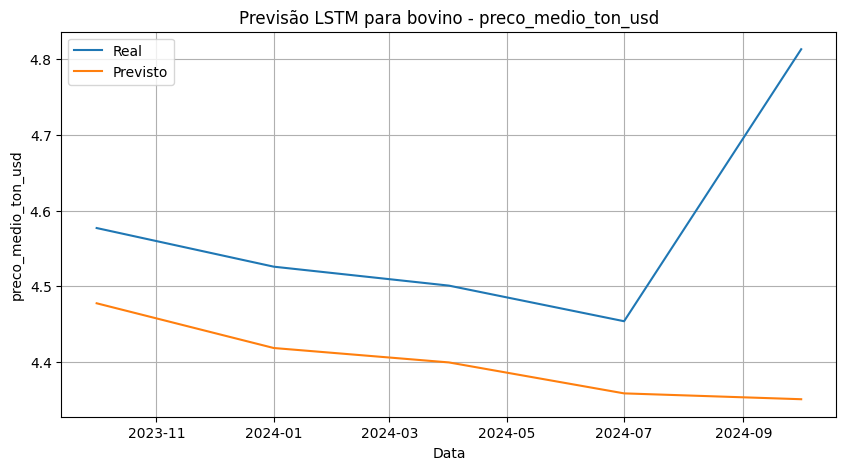

In [8]:
# Visualizar resultados
plt.figure(figsize=(10, 5))
plt.plot(filtered["date"].iloc[train_size + sequence_length:].reset_index(drop=True), actuals.flatten(), label="Real")
plt.plot(filtered["date"].iloc[train_size + sequence_length:].reset_index(drop=True), predictions.flatten(), label="Previsto")
plt.title(f"Previsão LSTM para {meat_type} - {feature_column}")
plt.xlabel("Data")
plt.ylabel(feature_column)
plt.legend()
plt.grid(True)
plt.show()